# Task-05: Evaluation and Visualization

This notebook collects the final prediction outputs, counting visualizations, processed results, metrics, strengths, limitations, and challenges faced.

The main source file is:

```txt
src/evaluate_visualize.py
```

## 1. Install Dependencies

In [1]:
!pip install -q ultralytics opencv-python pandas matplotlib pyyaml tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.1 MB/s eta 0:00:00


## 2. Set Project Root

In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path('/content/drone-human-car-detection')
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path('..').resolve()

os.chdir(PROJECT_ROOT)

print('Project root:', PROJECT_ROOT)
print('Current working directory:', Path.cwd())

Project root: /content/drone-human-car-detection
Current working directory: /content/drone-human-car-detection


## 4. Download VisDrone Dataset from Kaggle

This uses the Kaggle dataset link:

`https://www.kaggle.com/datasets/banuprasadb/visdrone-dataset?resource=download`

The code below downloads the dataset using `kagglehub` and links/copies it into:

```txt
data/VisDrone_Dataset/
```

If the automatic download fails, manually download the dataset from Kaggle, upload it to Colab/Drive, unzip it, and place it at `data/VisDrone_Dataset/`.

In [7]:
import kagglehub
from pathlib import Path
import shutil
import os

%cd /content/drone-human-car-detection

DATA_DIR = Path("data")
DATA_ROOT = DATA_DIR / "VisDrone_Dataset"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Downloading dataset from Kaggle...")
raw_path = Path(kagglehub.dataset_download("banuprasadb/visdrone-dataset"))
print("KaggleHub dataset path:", raw_path)

# Try to locate the actual VisDrone dataset root.
candidates = []

# Case 1: A folder named VisDrone_Dataset exists.
candidates.extend([p for p in raw_path.rglob("VisDrone_Dataset") if p.is_dir()])

# Case 2: The raw_path itself contains the train folder.
if (raw_path / "VisDrone2019-DET-train").exists():
    candidates.append(raw_path)

# Case 3: Find train folder and use its parent.
for train_folder in raw_path.rglob("VisDrone2019-DET-train"):
    if train_folder.is_dir():
        candidates.append(train_folder.parent)

# Remove duplicates while preserving order.
unique_candidates = []
seen = set()
for c in candidates:
    c_resolved = c.resolve()
    if c_resolved not in seen:
        unique_candidates.append(c)
        seen.add(c_resolved)

if not unique_candidates:
    raise FileNotFoundError(
        "Could not automatically find VisDrone2019-DET-train. "
        "Please inspect the downloaded dataset path and set DATA_ROOT manually."
    )

source_root = unique_candidates[0]
print("Detected source dataset root:", source_root)

# Remove old path/link if exists.
if DATA_ROOT.exists() or DATA_ROOT.is_symlink():
    if DATA_ROOT.is_symlink() or DATA_ROOT.is_file():
        DATA_ROOT.unlink()
    else:
        shutil.rmtree(DATA_ROOT)

# Symlink is faster and saves space. If symlink fails, copy the dataset.
try:
    os.symlink(source_root, DATA_ROOT, target_is_directory=True)
    print("Created symlink:", DATA_ROOT, "->", source_root)
except Exception as e:
    print("Symlink failed, copying instead:", e)
    shutil.copytree(source_root, DATA_ROOT)
    print("Copied dataset to:", DATA_ROOT)

print("\\nDataset root content:")
!ls data/VisDrone_Dataset

/content


100%|██████████| 2.10G/2.10G [00:16<00:00, 133MB/s]

Extracting files...


KaggleHub dataset path: /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1
Detected source dataset root: /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset
Created symlink: data/VisDrone_Dataset -> /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset
\nDataset root content:
VisDrone2019-DET-test-challenge  VisDrone2019-DET-train  visdrone.yaml
VisDrone2019-DET-test-dev	 VisDrone2019-DET-val


## 5. Verify Dataset Structure

The dataset should contain training and validation image/label folders.

In [8]:
from pathlib import Path

DATA_ROOT = Path("data/VisDrone_Dataset")

TRAIN_IMG_DIR = DATA_ROOT / "VisDrone2019-DET-train" / "images"
TRAIN_LABEL_DIR = DATA_ROOT / "VisDrone2019-DET-train" / "labels"

VAL_IMG_DIR = DATA_ROOT / "VisDrone2019-DET-val" / "images"
VAL_LABEL_DIR = DATA_ROOT / "VisDrone2019-DET-val" / "labels"

print("Train images exists:", TRAIN_IMG_DIR.exists())
print("Train labels exists:", TRAIN_LABEL_DIR.exists())
print("Validation images exists:", VAL_IMG_DIR.exists())
print("Validation labels exists:", VAL_LABEL_DIR.exists())

train_images = list(TRAIN_IMG_DIR.glob("*.jpg")) + list(TRAIN_IMG_DIR.glob("*.png"))
train_labels = list(TRAIN_LABEL_DIR.glob("*.txt"))

val_images = list(VAL_IMG_DIR.glob("*.jpg")) + list(VAL_IMG_DIR.glob("*.png"))
val_labels = list(VAL_LABEL_DIR.glob("*.txt"))

print("\nTraining images:", len(train_images))
print("Training labels:", len(train_labels))
print("Validation images:", len(val_images))
print("Validation labels:", len(val_labels))

Train images exists: True
Train labels exists: True
Validation images exists: True
Validation labels exists: True

Training images: 6471
Training labels: 6471
Validation images: 548
Validation labels: 548


## 3. Create `src/evaluate_visualize.py`

In [14]:
%%writefile src/evaluate_visualize.py
from pathlib import Path
import argparse
import shutil
import time
import pandas as pd
import cv2


def find_best_model(run_name="yolo_human_car"):
    candidates = []
    for root in [Path("runs"), Path("."), Path("outputs")]:
        if root.exists():
            candidates += [p for p in root.rglob("best.pt") if run_name in str(p) or p.name == "best.pt"]
    if not candidates:
        return None
    return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]


def read_csv(path):
    path = Path(path)
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def get_training_metrics(results_csv):
    df = read_csv(results_csv)
    if df is None or df.empty:
        return {}

    last = df.iloc[-1]
    metrics = {
        "precision": float(last["metrics/precision(B)"]) if "metrics/precision(B)" in df.columns else None,
        "recall": float(last["metrics/recall(B)"]) if "metrics/recall(B)" in df.columns else None,
        "mAP50": float(last["metrics/mAP50(B)"]) if "metrics/mAP50(B)" in df.columns else None,
        "mAP50_95": float(last["metrics/mAP50-95(B)"]) if "metrics/mAP50-95(B)" in df.columns else None,
        "total_epochs": int(len(df)),
    }

    if "metrics/mAP50(B)" in df.columns:
        best_idx = df["metrics/mAP50(B)"].idxmax()
        metrics["best_epoch_by_mAP50"] = int(df.loc[best_idx, "epoch"]) if "epoch" in df.columns else int(best_idx + 1)

    return metrics


def get_count_metrics(count_csv):
    df = read_csv(count_csv)
    if df is None or df.empty:
        return {}

    return {
        "processed_images": int(len(df)),
        "total_humans_detected": int(df["human_count"].sum()) if "human_count" in df.columns else None,
        "total_cars_detected": int(df["car_count"].sum()) if "car_count" in df.columns else None,
        "avg_humans_per_image": float(df["human_count"].mean()) if "human_count" in df.columns else None,
        "avg_cars_per_image": float(df["car_count"].mean()) if "car_count" in df.columns else None,
        "max_humans_in_image": int(df["human_count"].max()) if "human_count" in df.columns else None,
        "max_cars_in_image": int(df["car_count"].max()) if "car_count" in df.columns else None,
    }


def get_tracking_metrics(tracking_csv):
    df = read_csv(tracking_csv)
    if df is None or df.empty:
        return {"tracking_available": False}

    return {
        "tracking_available": True,
        "tracking_frames": int(len(df)),
        "unique_humans": int(df["unique_humans_so_far"].max()) if "unique_humans_so_far" in df.columns else None,
        "unique_cars": int(df["unique_cars_so_far"].max()) if "unique_cars_so_far" in df.columns else None,
    }


def copy_images(src_dir, dst_dir, limit=5):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    if not src_dir.exists():
        return []

    images = sorted(
        list(src_dir.glob("*.jpg")) +
        list(src_dir.glob("*.jpeg")) +
        list(src_dir.glob("*.png"))
    )

    copied = []
    for img in images[:limit]:
        out = dst_dir / img.name
        shutil.copy2(img, out)
        copied.append(out)

    return copied


def create_collage(image_paths, output_path, width=420):
    if not image_paths:
        return

    resized_images = []

    for p in image_paths[:3]:
        img = cv2.imread(str(p))
        if img is None:
            continue

        h, w = img.shape[:2]
        new_h = int(h * (width / w))
        img = cv2.resize(img, (width, new_h))
        resized_images.append(img)

    if not resized_images:
        return

    max_h = max(img.shape[0] for img in resized_images)
    padded = []

    for img in resized_images:
        h, w = img.shape[:2]
        if h < max_h:
            img = cv2.copyMakeBorder(img, 0, max_h - h, 0, 0, cv2.BORDER_CONSTANT, value=(255, 255, 255))
        padded.append(img)

    collage = cv2.hconcat(padded)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), collage)


def benchmark_fps(model_path, source_dir, imgsz=640, conf=0.25, max_images=10):
    if model_path is None or not Path(model_path).exists():
        return None

    source_dir = Path(source_dir)
    if not source_dir.exists():
        return None

    images = sorted(list(source_dir.glob("*.jpg")) + list(source_dir.glob("*.jpeg")) + list(source_dir.glob("*.png")))[:max_images]
    if not images:
        return None

    from ultralytics import YOLO
    model = YOLO(str(model_path))

    # warm-up
    model.predict(str(images[0]), imgsz=imgsz, conf=conf, verbose=False)

    start = time.time()
    for img in images:
        model.predict(str(img), imgsz=imgsz, conf=conf, verbose=False)
    elapsed = time.time() - start

    return len(images) / elapsed if elapsed > 0 else None


def fmt(x, digits=4):
    if x is None:
        return "N/A"
    if isinstance(x, float):
        return f"{x:.{digits}f}"
    return str(x)


def write_report(path, metrics, count_metrics, tracking_metrics, fps):
    report = f"""# Task-05: Evaluation and Visualization Report

Task-05 summarizes the final outputs of the drone human and car detection pipeline.

---

## Prediction Outputs

Prediction outputs are available in:

```txt
outputs/task02/sample_predictions/
```

These images show predicted bounding boxes for:

```txt
human
car
```

---

## Counting Visualization

Counting visualizations are available in:

```txt
outputs/task03/processed_images/
```

Each processed image displays human/car bounding boxes and the total human count.

---

## Processed Results

Selected final results are collected in:

```txt
outputs/task05/
├── selected_prediction_outputs/
├── selected_counting_visualizations/
├── selected_tracking_outputs/
├── prediction_collage.jpg
├── counting_collage.jpg
├── metrics_summary.csv
└── evaluation_summary.md
```

---

## Metrics

| Metric | Value |
|---|---:|
| Precision | {fmt(metrics.get("precision"))} |
| Recall | {fmt(metrics.get("recall"))} |
| mAP50 | {fmt(metrics.get("mAP50"))} |
| mAP50-95 | {fmt(metrics.get("mAP50_95"))} |
| Total Epochs | {fmt(metrics.get("total_epochs"))} |
| Best Epoch by mAP50 | {fmt(metrics.get("best_epoch_by_mAP50"))} |
| Approx. FPS | {fmt(fps, 2)} |

---

## Counting Summary

| Item | Value |
|---|---:|
| Processed Images | {fmt(count_metrics.get("processed_images"))} |
| Total Humans Detected | {fmt(count_metrics.get("total_humans_detected"))} |
| Total Cars Detected | {fmt(count_metrics.get("total_cars_detected"))} |
| Average Humans per Image | {fmt(count_metrics.get("avg_humans_per_image"), 2)} |
| Average Cars per Image | {fmt(count_metrics.get("avg_cars_per_image"), 2)} |
| Maximum Humans in One Image | {fmt(count_metrics.get("max_humans_in_image"))} |
| Maximum Cars in One Image | {fmt(count_metrics.get("max_cars_in_image"))} |

---

## Tracking Summary

| Item | Value |
|---|---:|
| Tracking Available | {tracking_metrics.get("tracking_available", False)} |
| Tracking Frames | {fmt(tracking_metrics.get("tracking_frames"))} |
| Unique Human IDs | {fmt(tracking_metrics.get("unique_humans"))} |
| Unique Car IDs | {fmt(tracking_metrics.get("unique_cars"))} |

---

## Strengths

- The project covers the full computer vision workflow: dataset understanding, preprocessing, model training, detection, counting, visualization, evaluation, and optional tracking.
- YOLOv8 is lightweight and suitable for fast object detection.
- The dataset was filtered into two task-specific classes: `human` and `car`.
- The counting visualization clearly displays the total human count on processed images.
- CSV summaries make the outputs easier to inspect and reproduce.
- ByteTrack adds temporal object association across consecutive frames.

---

## Limitations

- Humans are often very small in drone images, making them harder to detect than cars.
- Dense scenes may cause overlapping labels and bounding boxes.
- Occlusion, shadows, overexposure, and motion blur can reduce detection quality.
- Counting is based on detections, so missed detections reduce the final count.
- Cars are tracked more consistently than humans because they are larger and easier to detect from aerial views.

---

## Challenges Faced

- The original VisDrone dataset contains many classes, so it had to be filtered into `human` and `car`.
- Local CPU training was slow, so Google Colab GPU training was used.
- Aerial images contain strong scale variation, lighting variation, and dense object layouts.
- Tracking required ordered frames; random images are not ideal for tracking.

---

## Conclusion

The final system successfully detects humans and cars, displays bounding boxes, counts total humans, visualizes processed results, reports model metrics, and optionally tracks objects using ByteTrack.
"""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(report, encoding="utf-8")


def main():
    parser = argparse.ArgumentParser(description="Create Task-05 evaluation and visualization summary.")
    parser.add_argument("--results-csv", default="outputs/task02/results.csv")
    parser.add_argument("--counts-csv", default="outputs/task03/detection_counts.csv")
    parser.add_argument("--tracking-csv", default="outputs/task04/tracking_summary.csv")
    parser.add_argument("--prediction-dir", default="outputs/task02/sample_predictions")
    parser.add_argument("--counting-dir", default="outputs/task03/processed_images")
    parser.add_argument("--tracking-dir", default="outputs/task04/tracked_frames")
    parser.add_argument("--output-dir", default="outputs/task05")
    parser.add_argument("--model", default=None)
    parser.add_argument("--run-name", default="yolo_human_car")
    parser.add_argument("--fps-source", default="outputs/task02/sample_inputs")
    parser.add_argument("--imgsz", type=int, default=640)
    parser.add_argument("--conf", type=float, default=0.25)
    parser.add_argument("--max-images", type=int, default=10)
    args = parser.parse_args()

    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    metrics = get_training_metrics(args.results_csv)
    count_metrics = get_count_metrics(args.counts_csv)
    tracking_metrics = get_tracking_metrics(args.tracking_csv)

    model_path = Path(args.model) if args.model and Path(args.model).exists() else find_best_model(args.run_name)
    fps = benchmark_fps(model_path, args.fps_source, args.imgsz, args.conf, args.max_images)

    pred_imgs = copy_images(args.prediction_dir, output_dir / "selected_prediction_outputs")
    count_imgs = copy_images(args.counting_dir, output_dir / "selected_counting_visualizations")
    track_imgs = copy_images(args.tracking_dir, output_dir / "selected_tracking_outputs")

    create_collage(pred_imgs, output_dir / "prediction_collage.jpg")
    create_collage(count_imgs, output_dir / "counting_collage.jpg")
    create_collage(track_imgs, output_dir / "tracking_collage.jpg")

    summary = {
        **metrics,
        **count_metrics,
        **tracking_metrics,
        "fps": fps
    }
    pd.DataFrame([summary]).to_csv(output_dir / "metrics_summary.csv", index=False)

    write_report(output_dir / "evaluation_summary.md", metrics, count_metrics, tracking_metrics, fps)

    print("Task-05 evaluation complete.")
    print("Output folder:", output_dir)
    print("Metrics summary:", output_dir / "metrics_summary.csv")
    print("Evaluation report:", output_dir / "evaluation_summary.md")


if __name__ == "__main__":
    main()


Overwriting src/evaluate_visualize.py


## 4. Check Existing Outputs

In [15]:
paths_to_check = [
    'outputs/task02/results.png',
    'outputs/task02/results.csv',
    'outputs/task02/confusion_matrix.png',
    'outputs/task02/sample_predictions',
    'outputs/task03/processed_images',
    'outputs/task03/detection_counts.csv',
    'outputs/task04/tracked_frames',
    'outputs/task04/tracking_summary.csv',
    'outputs/task04/tracking_output.mp4',
]

for p in paths_to_check:
    path = PROJECT_ROOT / p
    print(f'{p}:', path.exists())

outputs/task02/results.png: True
outputs/task02/results.csv: True
outputs/task02/confusion_matrix.png: True
outputs/task02/sample_predictions: True
outputs/task03/processed_images: True
outputs/task03/detection_counts.csv: True
outputs/task04/tracked_frames: True
outputs/task04/tracking_summary.csv: True
outputs/task04/tracking_output.mp4: True


## 5. Run Task-05 Evaluation

In [16]:
!python src/evaluate_visualize.py \
    --results-csv outputs/task02/results.csv \
    --counts-csv outputs/task03/detection_counts.csv \
    --tracking-csv outputs/task04/tracking_summary.csv \
    --prediction-dir outputs/task02/sample_predictions \
    --counting-dir outputs/task03/processed_images \
    --tracking-dir outputs/task04/tracked_frames \
    --output-dir outputs/task05 \
    --imgsz 640 \
    --conf 0.25 \
    --max-images 10

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Task-05 evaluation complete.
Output folder: outputs/task05
Metrics summary: outputs/task05/metrics_summary.csv
Evaluation report: outputs/task05/evaluation_summary.md


## 6. View Metrics Summary

In [17]:
import pandas as pd

metrics_path = PROJECT_ROOT / 'outputs' / 'task05' / 'metrics_summary.csv'

if metrics_path.exists():
    display(pd.read_csv(metrics_path))
else:
    print('metrics_summary.csv not found.')

,precision,recall,mAP50,mAP50_95,total_epochs,best_epoch_by_mAP50,processed_images,total_humans_detected,total_cars_detected,avg_humans_per_image,avg_cars_per_image,max_humans_in_image,max_cars_in_image,tracking_available,tracking_frames,unique_humans,unique_cars,fps
0,0.69164,0.53395,0.57356,0.31669,50,50,10,134,197,13.4,19.7,39,57,True,35,8,52,66.582912


## 7. Display Prediction Collage

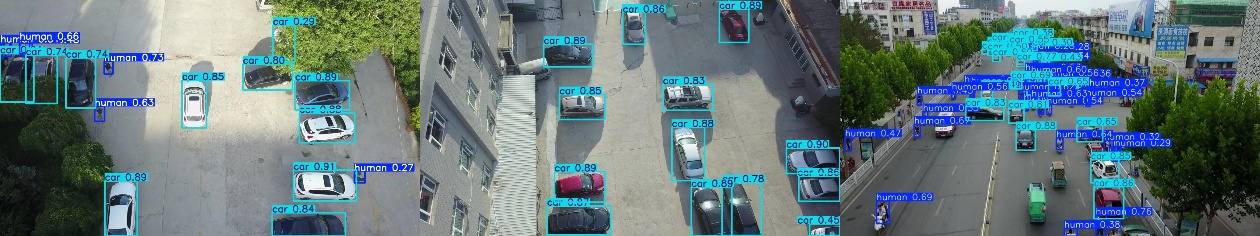

In [18]:
from IPython.display import Image, display

prediction_collage = PROJECT_ROOT / 'outputs' / 'task05' / 'prediction_collage.jpg'

if prediction_collage.exists():
    display(Image(filename=str(prediction_collage)))
else:
    print('prediction_collage.jpg not found.')

## 8. Display Counting Collage

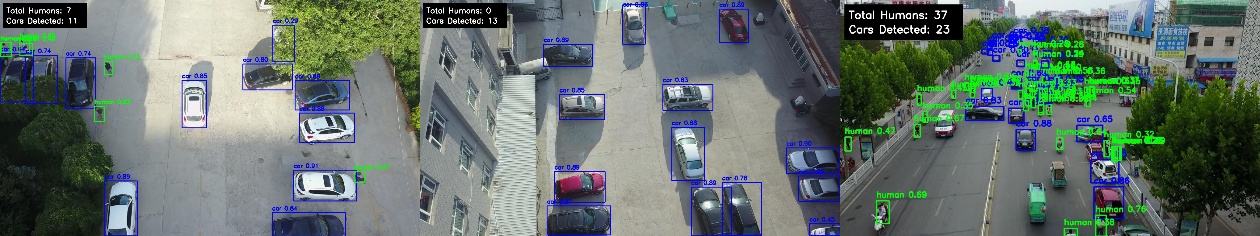

In [19]:
counting_collage = PROJECT_ROOT / 'outputs' / 'task05' / 'counting_collage.jpg'

if counting_collage.exists():
    display(Image(filename=str(counting_collage)))
else:
    print('counting_collage.jpg not found.')

## 9. Display Evaluation Report

In [20]:
from IPython.display import Markdown, display

report_path = PROJECT_ROOT / 'outputs' / 'task05' / 'evaluation_summary.md'

if report_path.exists():
    display(Markdown(report_path.read_text(encoding='utf-8')))
else:
    print('evaluation_summary.md not found.')

# Task-05: Evaluation and Visualization Report

Task-05 summarizes the final outputs of the drone human and car detection pipeline.

---

## Prediction Outputs

Prediction outputs are available in:

```txt
outputs/task02/sample_predictions/
```

These images show predicted bounding boxes for:

```txt
human
car
```

---

## Counting Visualization

Counting visualizations are available in:

```txt
outputs/task03/processed_images/
```

Each processed image displays human/car bounding boxes and the total human count.

---

## Processed Results

Selected final results are collected in:

```txt
outputs/task05/
├── selected_prediction_outputs/
├── selected_counting_visualizations/
├── selected_tracking_outputs/
├── prediction_collage.jpg
├── counting_collage.jpg
├── metrics_summary.csv
└── evaluation_summary.md
```

---

## Metrics

| Metric | Value |
|---|---:|
| Precision | 0.6916 |
| Recall | 0.5340 |
| mAP50 | 0.5736 |
| mAP50-95 | 0.3167 |
| Total Epochs | 50 |
| Best Epoch by mAP50 | 50 |
| Approx. FPS | 66.58 |

---

## Counting Summary

| Item | Value |
|---|---:|
| Processed Images | 10 |
| Total Humans Detected | 134 |
| Total Cars Detected | 197 |
| Average Humans per Image | 13.40 |
| Average Cars per Image | 19.70 |
| Maximum Humans in One Image | 39 |
| Maximum Cars in One Image | 57 |

---

## Tracking Summary

| Item | Value |
|---|---:|
| Tracking Available | True |
| Tracking Frames | 35 |
| Unique Human IDs | 8 |
| Unique Car IDs | 52 |

---

## Strengths

- The project covers the full computer vision workflow: dataset understanding, preprocessing, model training, detection, counting, visualization, evaluation, and optional tracking.
- YOLOv8 is lightweight and suitable for fast object detection.
- The dataset was filtered into two task-specific classes: `human` and `car`.
- The counting visualization clearly displays the total human count on processed images.
- CSV summaries make the outputs easier to inspect and reproduce.
- ByteTrack adds temporal object association across consecutive frames.

---

## Limitations

- Humans are often very small in drone images, making them harder to detect than cars.
- Dense scenes may cause overlapping labels and bounding boxes.
- Occlusion, shadows, overexposure, and motion blur can reduce detection quality.
- Counting is based on detections, so missed detections reduce the final count.
- Cars are tracked more consistently than humans because they are larger and easier to detect from aerial views.

---

## Challenges Faced

- The original VisDrone dataset contains many classes, so it had to be filtered into `human` and `car`.
- Local CPU training was slow, so Google Colab GPU training was used.
- Aerial images contain strong scale variation, lighting variation, and dense object layouts.
- Tracking required ordered frames; random images are not ideal for tracking.

---

## Conclusion

The final system successfully detects humans and cars, displays bounding boxes, counts total humans, visualizes processed results, reports model metrics, and optionally tracks objects using ByteTrack.


## 10. Zip Task-05 Outputs

In [21]:
!zip -r outputs/task05.zip outputs/task05

  adding: outputs/task05/ (stored 0%)
  adding: outputs/task05/evaluation_summary.md (deflated 57%)
  adding: outputs/task05/metrics_summary.csv (deflated 41%)
  adding: outputs/task05/tracking_collage.jpg (deflated 0%)
  adding: outputs/task05/prediction_collage.jpg (deflated 0%)
  adding: outputs/task05/selected_tracking_outputs/ (stored 0%)
  adding: outputs/task05/selected_tracking_outputs/0000289_00601_d_0000814.jpg (deflated 4%)
  adding: outputs/task05/selected_tracking_outputs/0000289_00001_d_0000811.jpg (deflated 5%)
  adding: outputs/task05/selected_tracking_outputs/0000289_00201_d_0000812.jpg (deflated 5%)
  adding: outputs/task05/selected_tracking_outputs/0000289_00401_d_0000813.jpg (deflated 4%)
  adding: outputs/task05/selected_tracking_outputs/0000289_00801_d_0000815.jpg (deflated 5%)
  adding: outputs/task05/counting_collage.jpg (deflated 0%)
  adding: outputs/task05/selected_counting_visualizations/ (stored 0%)
  adding: outputs/task05/selected_counting_visualizations/

## Task-05 Output Structure

```txt
outputs/task05/
├── selected_prediction_outputs/
├── selected_counting_visualizations/
├── selected_tracking_outputs/
├── prediction_collage.jpg
├── counting_collage.jpg
├── tracking_collage.jpg
├── metrics_summary.csv
└── evaluation_summary.md
```